# Finance AI — Ciência de Dados do MVP

Notebook reproduzível para a entrega do Hackathon Fintech. O objetivo é transformar transações e indicadores financeiros em:

1. classificação automática de despesas;
2. análise do perfil financeiro;
3. métricas e explicações auditáveis;
4. modelos serializados para integração com a API.

> **Aviso:** o conjunto de dados é sintético. Os resultados demonstram a viabilidade técnica do MVP, mas não validam uso em produção sem dados reais, consentidos, anonimizados e tratados segundo a LGPD.

## 1. Escopo e critérios de validação

Este notebook cobre os entregáveis de Ciência de Dados solicitados:

- exploração e limpeza dos dados (EDA);
- tratamento de variáveis textuais e financeiras;
- engenharia de atributos e prevenção de vazamento;
- classificação de despesas;
- classificação de perfil financeiro;
- comparação, treinamento e avaliação de modelos;
- métricas por classe e matrizes de confusão;
- serialização isolada dos artefatos.

A coluna `split` do dataset é respeitada: `TRAIN` ajusta os modelos, `VALIDATION` escolhe a alternativa e `TEST` é consultado uma única vez na avaliação final. Como a divisão foi feita por usuário, também verificamos que não existe sobreposição de usuários entre os conjuntos.

### Dependências

Execute o notebook com o ambiente do `ai-service`. Se necessário:

```bash
cd ai-service
pip install -e .
pip install jupyter matplotlib
jupyter lab ../notebooks/finance_ai_data_science.ipynb
```

### Configuração de Caminhos via Variáveis de Ambiente

Para facilitar a portabilidade entre diferentes ambientes (como Google Colab e um ambiente de produção local/remoto), os caminhos para o diretório raiz (`ROOT`), dados (`DATA_DIR`) e artefatos (`ARTIFACTS_DIR`) agora são configuráveis via variáveis de ambiente.

Em um ambiente de produção, defina as variáveis `FINANCE_AI_ROOT`, `FINANCE_AI_DATA_DIR` e `FINANCE_AI_ARTIFACTS_DIR` para os caminhos desejados. No Google Colab, os valores padrão (`/content/` para `ROOT` e `DATA_DIR`, e `/content/ai-service/models/notebook-experiments` para `ARTIFACTS_DIR`) serão usados automaticamente como fallback.

In [1]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve().parent

FINANCE_AI_ROOT = PROJECT_ROOT
FINANCE_AI_DATA_DIR = PROJECT_ROOT / "finance_ai_dataset"
FINANCE_AI_ARTIFACTS_DIR = PROJECT_ROOT / "ai-service" / "models" / "notebook-experiments"

os.environ["FINANCE_AI_ROOT"] = str(FINANCE_AI_ROOT)
os.environ["FINANCE_AI_DATA_DIR"] = str(FINANCE_AI_DATA_DIR)
os.environ["FINANCE_AI_ARTIFACTS_DIR"] = str(FINANCE_AI_ARTIFACTS_DIR)

In [5]:
%pip install matplotlib numpy pandas scikit-learn joblib shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from __future__ import annotations

import json
import platform
import re
import unicodedata
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import os

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42

ROOT = Path(os.environ.get('FINANCE_AI_ROOT', '/content/'))
DATA_DIR = Path(os.environ.get('FINANCE_AI_DATA_DIR', str(ROOT)))
ARTIFACTS_DIR = Path(os.environ.get('FINANCE_AI_ARTIFACTS_DIR', str(ROOT / 'ai-service' / 'models' / 'notebook-experiments')))
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raiz do projeto: {ROOT}')
print(f'Dados: {DATA_DIR}')
print(f'Artefatos isolados: {ARTIFACTS_DIR}')
print(f'Python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}')

Raiz do projeto: D:\ONE 10\Projeto GitHub\G9-BR-Team-17-FinVise
Dados: D:\ONE 10\Projeto GitHub\G9-BR-Team-17-FinVise\finance_ai_dataset
Artefatos isolados: D:\ONE 10\Projeto GitHub\G9-BR-Team-17-FinVise\ai-service\models\notebook-experiments
Python 3.13.5 | pandas 2.3.0 | scikit-learn 1.9.0


## 2. Carregamento e auditoria dos dados

Carregamos transações e perfis mensais diretamente das fontes versionadas. Nenhuma amostra é descartada antes da auditoria de qualidade.

In [7]:
transactions_raw = pd.read_csv(
    DATA_DIR / 'transacoes.csv',
    parse_dates=['data_transacao'],
    low_memory=False,
)
profiles_raw = pd.read_csv(DATA_DIR / 'perfis_mensais.csv', low_memory=False)

dataset_overview = pd.DataFrame({
    'dataset': ['transações', 'perfis mensais'],
    'linhas': [len(transactions_raw), len(profiles_raw)],
    'colunas': [transactions_raw.shape[1], profiles_raw.shape[1]],
    'duplicados_por_id': [
        int(transactions_raw.duplicated('transacao_id').sum()),
        int(profiles_raw.duplicated(['usuario_id', 'mes_referencia']).sum()),
    ],
})
display(dataset_overview)
display(transactions_raw.head(3))
display(profiles_raw.head(3))

,dataset,linhas,colunas,duplicados_por_id
0,transações,169546,19,0
1,perfis mensais,18000,21,0


,transacao_id,usuario_id,data_transacao,mes_referencia,descricao_original,descricao_normalizada,valor,tipo,categoria,subcategoria,estabelecimento,forma_pagamento,parcelas,recorrente,canal,estado,cidade,split,fonte
0,TX000000796,USR000008,2025-07-01,2025-07,PGTO Aluguel Residencial 3268 ALUG,pgto aluguel residencial 3268 alug,367.4200,DESPESA,MORADIA,ALUGUEL,Aluguel Residencial,PIX,1,1,POS,MG,Uberlandia,TRAIN,SINTETICO
1,TX000000801,USR000008,2025-07-01,2025-07,Microsoft 388,microsoft 388,70.7600,DESPESA,SERVICOS,ASSINATURA,Microsoft 365,DEBITO_AUTOMATICO,1,1,POS,MG,Uberlandia,TRAIN,SINTETICO
2,TX000000802,USR000008,2025-07-01,2025-07,Aluguel Residenci 502,aluguel residenci 502,417.8900,DESPESA,MORADIA,ALUGUEL,Aluguel Residencial,CARTAO_CREDITO,1,1,WEB,MG,Uberlandia,TRAIN,SINTETICO


,usuario_id,mes_referencia,renda_mensal,total_despesas,percentual_renda_comprometida,nivel_endividamento_pct,taxa_poupanca_pct,percentual_despesas_fixas,percentual_gastos_nao_essenciais,quantidade_despesas_recorrentes,quantidade_transacoes_despesa,variacao_despesas_pct,reserva_em_meses,score_financeiro,perfil_financeiro,confianca_perfil,fatores_risco,fatores_positivos,regra_rotulacao,split,fonte
0,USR000001,2025-07,"3,043.0300","2,020.3000",66.3900,0.0200,21.6200,42.8900,57.1100,3,4,0.0000,7.0800,100.0000,SAUDAVEL,0.8988,gastos_nao_essenciais_altos,despesas_controladas|baixo_endividamento|boa_t...,SCORE_SINTETICO_V1,TRAIN,SINTETICO
1,USR000002,2025-07,"4,910.8400","3,979.5700",81.0400,28.8900,5.2900,37.6200,57.4500,1,6,0.0000,3.3400,63.0000,EM_OBSERVACAO,0.7827,renda_comprometida|endividamento_moderado|baix...,reserva_adequada,SCORE_SINTETICO_V1,TRAIN,SINTETICO
2,USR000003,2025-07,"4,018.8000","4,572.8000",113.7900,71.4500,1.6700,37.9100,6.3100,4,8,0.0000,0.8600,5.0000,EM_RISCO,0.9547,despesas_acima_da_renda|endividamento_muito_al...,nenhum_relevante,SCORE_SINTETICO_V1,TRAIN,SINTETICO


In [8]:
def quality_report(frame: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame({
        'tipo': frame.dtypes.astype(str),
        'nulos': frame.isna().sum(),
        'nulos_pct': frame.isna().mean().mul(100),
        'unicos': frame.nunique(dropna=True),
    })
    return report.sort_values(['nulos_pct', 'unicos'], ascending=[False, True])

print('Qualidade — transações')
display(quality_report(transactions_raw).head(20))
print('Qualidade — perfis')
display(quality_report(profiles_raw).head(20))

split_audit = pd.concat([
    transactions_raw['split'].value_counts().rename('transações'),
    profiles_raw['split'].value_counts().rename('perfis'),
], axis=1).fillna(0).astype(int)
display(split_audit)

Qualidade — transações


,tipo,nulos,nulos_pct,unicos
fonte,object,0,0.0000,1
recorrente,int64,0,0.0000,2
tipo,object,0,0.0000,3
split,object,0,0.0000,3
canal,object,0,0.0000,6
parcelas,int64,0,0.0000,7
forma_pagamento,object,0,0.0000,8
mes_referencia,object,0,0.0000,12
categoria,object,0,0.0000,12
estado,object,0,0.0000,12


Qualidade — perfis


,tipo,nulos,nulos_pct,unicos
regra_rotulacao,object,0,0.0000,1
fonte,object,0,0.0000,1
perfil_financeiro,object,0,0.0000,3
split,object,0,0.0000,3
quantidade_despesas_recorrentes,int64,0,0.0000,11
quantidade_transacoes_despesa,int64,0,0.0000,11
mes_referencia,object,0,0.0000,12
fatores_positivos,object,0,0.0000,32
score_financeiro,float64,0,0.0000,90
fatores_risco,object,0,0.0000,271


,transações,perfis
split,,
TRAIN,118636,12600
VALIDATION,25478,2700
TEST,25432,2700


## 3. EDA das transações

O classificador do MVP trata somente despesas. Receitas continuam relevantes para os indicadores e para o perfil, mas não entram no target de categorias de despesa.

In [9]:
transaction_eda = pd.DataFrame({
    'indicador': [
        'período inicial', 'período final', 'usuários', 'transações',
        'receitas', 'despesas', 'valor mediano', 'valor p95',
    ],
    'valor': [
        transactions_raw['data_transacao'].min().date(),
        transactions_raw['data_transacao'].max().date(),
        transactions_raw['usuario_id'].nunique(),
        len(transactions_raw),
        int((transactions_raw['tipo'] == 'RECEITA').sum()),
        int((transactions_raw['tipo'] == 'DESPESA').sum()),
        float(transactions_raw['valor'].median()),
        float(transactions_raw['valor'].quantile(0.95)),
    ],
})
display(transaction_eda)

category_summary = (
    transactions_raw.query("tipo == 'DESPESA'")
    .groupby('categoria', observed=True)
    .agg(transacoes=('transacao_id', 'size'), valor_total=('valor', 'sum'), valor_mediano=('valor', 'median'))
    .sort_values('transacoes', ascending=False)
)
category_summary['participacao_pct'] = category_summary['transacoes'].div(category_summary['transacoes'].sum()).mul(100)
display(category_summary)

,indicador,valor
0,período inicial,2025-07-01
1,período final,2026-06-28
2,usuários,1500
3,transações,169546
4,receitas,20474
5,despesas,131313
6,valor mediano,473.6850
7,valor p95,"5,348.4475"


,transacoes,valor_total,valor_mediano,participacao_pct
categoria,,,,
MORADIA,34927,"23,224,180.0400",404.6400,26.5983
ALIMENTACAO,34431,"22,705,288.2300",404.1400,26.2206
SERVICOS,23917,"16,693,208.0700",424.2900,18.2137
TRANSPORTE,8984,"5,283,988.5400",361.3150,6.8417
LAZER,6441,"3,924,135.0800",366.6100,4.9051
SAUDE,5973,"3,586,234.8100",361.2200,4.5487
COMPRAS,5886,"3,561,316.4400",369.1350,4.4824
EDUCACAO,4831,"2,851,242.6100",364.6700,3.6790
DIVIDAS,4352,"2,823,754.4300",400.5000,3.3142


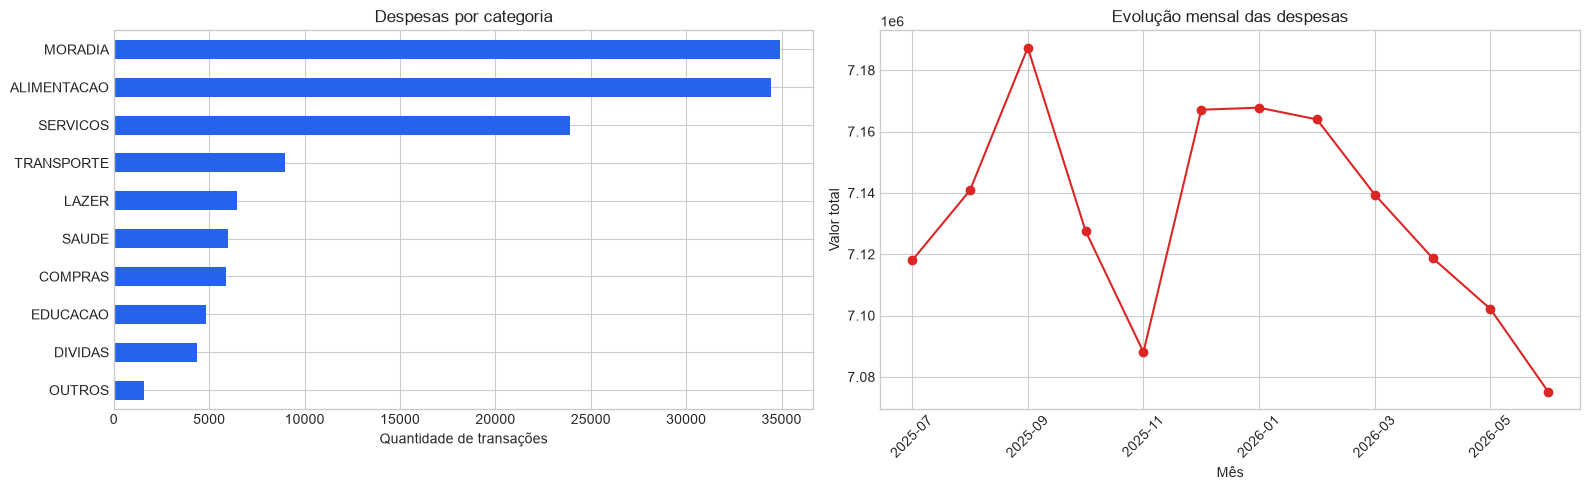

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
category_summary.sort_values('transacoes')['transacoes'].plot.barh(
    ax=axes[0], color='#2563eb', title='Despesas por categoria'
)
axes[0].set_xlabel('Quantidade de transações')
axes[0].set_ylabel('')

monthly_expenses = (
    transactions_raw.query("tipo == 'DESPESA'")
    .groupby('mes_referencia', observed=True)['valor'].sum()
)
monthly_expenses.plot(ax=axes[1], color='#dc2626', marker='o', title='Evolução mensal das despesas')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Valor total')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Limpeza e tratamento textual

A descrição é auditada com Unicode NFKD, remoção de acentos, caixa baixa, remoção de caracteres não alfanuméricos e espaços redundantes. IDs duplicados, descrições vazias e valores não positivos são removidos. No artefato final, a normalização usa os parâmetros nativos e serializáveis do TF-IDF (`lowercase` e `strip_accents`), garantindo o mesmo tratamento em treino e inferência sem depender de funções definidas no notebook.

In [11]:
def normalize_description(value: object) -> str:
    text = '' if pd.isna(value) else str(value)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip()

transactions = transactions_raw.copy()
transactions['split'] = transactions['split'].str.upper().str.strip()
transactions = transactions.query("tipo == 'DESPESA'").copy()
transactions = transactions.drop_duplicates('transacao_id')
transactions = transactions.dropna(subset=['descricao_original', 'categoria', 'valor', 'usuario_id'])
transactions = transactions.loc[transactions['valor'].gt(0)].copy()
transactions['texto_modelo'] = transactions['descricao_original'].map(normalize_description)
transactions = transactions.loc[transactions['texto_modelo'].str.len().gt(0)].copy()

cleaning_summary = {
    'despesas_originais': int((transactions_raw['tipo'] == 'DESPESA').sum()),
    'despesas_após_limpeza': len(transactions),
    'linhas_removidas': int((transactions_raw['tipo'] == 'DESPESA').sum() - len(transactions)),
    'categorias': transactions['categoria'].nunique(),
    'subcategorias': transactions['subcategoria'].nunique(),
}
display(pd.Series(cleaning_summary, name='valor').to_frame())
display(transactions[['descricao_original', 'texto_modelo', 'categoria', 'subcategoria']].sample(5, random_state=RANDOM_STATE))

,valor
despesas_originais,131313
despesas_após_limpeza,131313
linhas_removidas,0
categorias,10
subcategorias,39


,descricao_original,texto_modelo,categoria,subcategoria
136840,COMPRA Conta de Energia,compra conta de energia,MORADIA,ENERGIA
66425,LANC McDonalds CE,lanc mcdonalds ce,ALIMENTACAO,RESTAURANTE
97656,PGTO Restaurante Sabor Caseiro BA,pgto restaurante sabor caseiro ba,ALIMENTACAO,RESTAURANTE
96567,Tokio*Marine SEGU,tokio marine segu,SERVICOS,SEGURO
12218,Pao de Acucar,pao de acucar,ALIMENTACAO,SUPERMERCADO


In [12]:
transaction_splits = {
    split: transactions.loc[transactions['split'].eq(split)].copy()
    for split in ('TRAIN', 'VALIDATION', 'TEST')
}

def assert_user_isolation(splits: dict[str, pd.DataFrame]) -> None:
    users = {name: set(frame['usuario_id']) for name, frame in splits.items()}
    for left, right in (('TRAIN', 'VALIDATION'), ('TRAIN', 'TEST'), ('VALIDATION', 'TEST')):
        overlap = users[left].intersection(users[right])
        assert not overlap, f'Vazamento de usuários entre {left} e {right}: {len(overlap)}'

assert_user_isolation(transaction_splits)
display(pd.DataFrame({
    name: {'linhas': len(frame), 'usuarios': frame['usuario_id'].nunique()}
    for name, frame in transaction_splits.items()
}).T)
print('[OK] Não há usuários compartilhados entre TRAIN, VALIDATION e TEST.')

,linhas,usuarios
TRAIN,91882,1050
VALIDATION,19739,225
TEST,19692,225


[OK] Não há usuários compartilhados entre TRAIN, VALIDATION e TEST.


## 5. Classificador de despesas

O baseline combina TF-IDF de unigramas e bigramas com Regressão Logística balanceada. Essa arquitetura é adequada ao MVP por ser rápida, serializável e explicável por coeficientes. O conjunto `TEST` permanece intocado até a avaliação final.

In [13]:
transaction_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=2,
        max_features=20_000,
        sublinear_tf=True,
    )),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1_000,
        random_state=RANDOM_STATE,
    )),
])

tx_train = transaction_splits['TRAIN']
tx_validation = transaction_splits['VALIDATION']
tx_test = transaction_splits['TEST']

transaction_pipeline.fit(tx_train['descricao_original'], tx_train['categoria'])
print(f'Vocabulário TF-IDF: {len(transaction_pipeline.named_steps["tfidf"].vocabulary_):,} termos')

Vocabulário TF-IDF: 4,974 termos


In [14]:
def to_builtin(value):
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

def evaluate_model(model, X, y, labels: list[str], split_name: str):
    predictions = model.predict(X)
    report = classification_report(y, predictions, output_dict=True, zero_division=0)
    metrics = {
        'split': split_name,
        'samples': len(y),
        'accuracy': accuracy_score(y, predictions),
        'macro_f1': f1_score(y, predictions, average='macro', zero_division=0),
        'weighted_f1': f1_score(y, predictions, average='weighted', zero_division=0),
        'classification_report': report,
        'confusion_matrix': confusion_matrix(y, predictions, labels=labels),
        'labels': labels,
    }
    summary = pd.Series({key: metrics[key] for key in ('samples', 'accuracy', 'macro_f1', 'weighted_f1')}, name=split_name)
    display(summary.to_frame())
    display(pd.DataFrame(report).T.round(4))
    return to_builtin(metrics), predictions

transaction_labels = sorted(transactions['categoria'].unique())
tx_validation_metrics, tx_validation_predictions = evaluate_model(
    transaction_pipeline, tx_validation['descricao_original'], tx_validation['categoria'],
    transaction_labels, 'VALIDATION',
)

,VALIDATION
samples,"19,739.0000"
accuracy,0.9998
macro_f1,0.9997
weighted_f1,0.9998


,precision,recall,f1-score,support
ALIMENTACAO,1.0000,0.9994,0.9997,"5,194.0000"
COMPRAS,0.9967,1.0000,0.9983,906.0000
DIVIDAS,1.0000,1.0000,1.0000,605.0000
EDUCACAO,1.0000,1.0000,1.0000,732.0000
LAZER,1.0000,0.9990,0.9995,959.0000
MORADIA,1.0000,1.0000,1.0000,"5,200.0000"
OUTROS,1.0000,1.0000,1.0000,250.0000
SAUDE,1.0000,1.0000,1.0000,927.0000
SERVICOS,1.0000,1.0000,1.0000,"3,594.0000"
TRANSPORTE,0.9993,1.0000,0.9996,"1,372.0000"


### Avaliação final do classificador

Após validar a arquitetura, o modelo final é reajustado com `TRAIN + VALIDATION`. Somente então o conjunto `TEST` é usado para a métrica final.

,TEST
samples,"19,692.0000"
accuracy,0.9999
macro_f1,0.9999
weighted_f1,0.9999


,precision,recall,f1-score,support
ALIMENTACAO,1.0000,0.9996,0.9998,"5,150.0000"
COMPRAS,0.9977,1.0000,0.9988,850.0000
DIVIDAS,1.0000,1.0000,1.0000,700.0000
EDUCACAO,1.0000,1.0000,1.0000,707.0000
LAZER,1.0000,1.0000,1.0000,966.0000
MORADIA,1.0000,1.0000,1.0000,"5,275.0000"
OUTROS,1.0000,1.0000,1.0000,240.0000
SAUDE,1.0000,1.0000,1.0000,851.0000
SERVICOS,1.0000,1.0000,1.0000,"3,576.0000"
TRANSPORTE,1.0000,1.0000,1.0000,"1,377.0000"


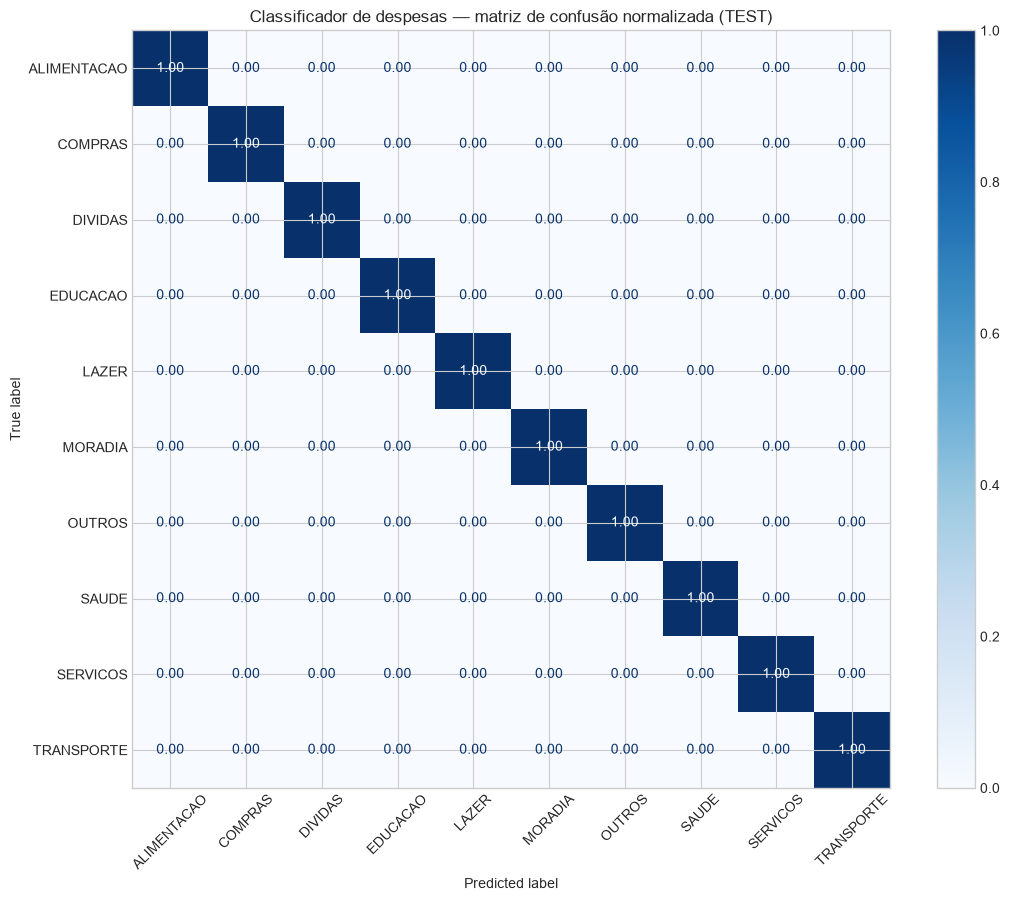

In [15]:
transaction_final = clone(transaction_pipeline)
tx_train_validation = pd.concat([tx_train, tx_validation], ignore_index=True)
transaction_final.fit(tx_train_validation['descricao_original'], tx_train_validation['categoria'])
tx_test_metrics, tx_test_predictions = evaluate_model(
    transaction_final, tx_test['descricao_original'], tx_test['categoria'],
    transaction_labels, 'TEST',
)

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    tx_test['categoria'], tx_test_predictions, labels=transaction_labels,
    normalize='true', cmap='Blues', xticks_rotation=45, values_format='.2f', ax=ax,
)
ax.set_title('Classificador de despesas — matriz de confusão normalizada (TEST)')
plt.tight_layout()
plt.show()

In [16]:
tx_error_analysis = tx_test[['descricao_original', 'categoria']].copy()
tx_error_analysis['predicao'] = tx_test_predictions
tx_error_analysis['confianca'] = transaction_final.predict_proba(tx_test['descricao_original']).max(axis=1)
tx_errors = tx_error_analysis.loc[tx_error_analysis['categoria'].ne(tx_error_analysis['predicao'])]
print(f'Erros no conjunto TEST: {len(tx_errors):,} de {len(tx_test):,}')
display(tx_errors.sort_values('confianca').head(20))

realistic_examples = pd.Series([
    'Supermercado Extra compra do mês',
    'Abastecimento posto Shell gasolina',
    'Mensalidade Netflix',
], name='descricao')
example_predictions = transaction_final.predict(realistic_examples)
example_probabilities = transaction_final.predict_proba(realistic_examples).max(axis=1)
display(pd.DataFrame({
    'descricao': realistic_examples,
    'categoria_prevista': example_predictions,
    'confianca': example_probabilities,
}))

Erros no conjunto TEST: 2 de 19,692


,descricao_original,categoria,predicao,confianca
131109,4taca 348,ALIMENTACAO,COMPRAS,0.2286
162618,4tacad 176,ALIMENTACAO,COMPRAS,0.2439


,descricao,categoria_prevista,confianca
0,Supermercado Extra compra do mês,ALIMENTACAO,0.9954
1,Abastecimento posto Shell gasolina,TRANSPORTE,0.9988
2,Mensalidade Netflix,LAZER,0.9952


### Fallback do Classificador de Despesas

A política de fallback é a seguinte: se a confiança da previsão do modelo for menor que um `threshold` definido (padrão de 0.8), a transação é marcada para `REVISAO_MANUAL`. Isso garante que apenas as previsões de alta confiança sejam aceitas automaticamente.

In [17]:
import pandas as pd

def classificar_despesa_com_fallback(descricao: str, threshold: float = 0.8) -> dict:
    """
    Classifica uma despesa usando o modelo final e aplica um fallback
    para revisão manual se a confiança for abaixo do threshold.

    Args:
        descricao (str): A descrição da transação.
        threshold (float): O limite de confiança para aceitar a previsão automática.

    Returns:
        dict: Um dicionário contendo a descrição, categoria prevista, confiança
              e um flag indicando se precisa de revisão.
    """
    # Certifica-se de que a entrada é um objeto que o modelo pode processar (e.g., Series ou list)
    descriptions_series = pd.Series([descricao])

    # Gera as probabilidades para a descrição
    probabilities = transaction_final.predict_proba(descriptions_series)

    # Encontra a maior probabilidade e a categoria correspondente
    confianca = probabilities.max(axis=1)[0]
    predicted_class_index = probabilities.argmax(axis=1)[0]
    categoria_prevista = transaction_final.named_steps['classifier'].classes_[predicted_class_index]

    if confianca >= threshold:
        return {
            "descricao": descricao,
            "categoria": categoria_prevista,
            "confianca": confianca,
            "precisa_revisao": False
        }
    else:
        return {
            "descricao": descricao,
            "categoria": "REVISAO_MANUAL",
            "confianca": confianca,
            "precisa_revisao": True
        }


### Demonstração do Fallback

In [18]:
# Exemplos de alta confiança
print('--- Exemplos de Alta Confiança ---')
example_high_confidence_1 = 'Supermercado Extra compra do mes'
example_high_confidence_2 = 'Pagamento Netflix mensalidade'

display(classificar_despesa_com_fallback(example_high_confidence_1, threshold=0.8))
display(classificar_despesa_com_fallback(example_high_confidence_2, threshold=0.8))

# Exemplos de baixa confiança (para cair no fallback)
print('\n--- Exemplos de Baixa Confiança ---')
# Descrição genérica ou ambígua para forçar baixa confiança
example_low_confidence_1 = 'Pagamento de serviço'
example_low_confidence_2 = 'Compra diversa'

display(classificar_despesa_com_fallback(example_low_confidence_1, threshold=0.8))
display(classificar_despesa_com_fallback(example_low_confidence_2, threshold=0.8))

# Exemplo com threshold diferente
print('\n--- Exemplo com Threshold Ajustado ---')
# A mesma descrição de alta confiança, mas com um threshold muito alto
display(classificar_despesa_com_fallback(example_high_confidence_1, threshold=0.99999))


--- Exemplos de Alta Confiança ---


{'descricao': 'Supermercado Extra compra do mes',
 'categoria': 'ALIMENTACAO',
 'confianca': np.float64(0.9953893304339612),
 'precisa_revisao': False}

{'descricao': 'Pagamento Netflix mensalidade',
 'categoria': 'LAZER',
 'confianca': np.float64(0.9539910358822379),
 'precisa_revisao': False}


--- Exemplos de Baixa Confiança ---


{'descricao': 'Pagamento de serviço',
 'categoria': 'OUTROS',
 'confianca': np.float64(0.8406233819747658),
 'precisa_revisao': False}

{'descricao': 'Compra diversa',
 'categoria': 'REVISAO_MANUAL',
 'confianca': np.float64(0.4485079123688),
 'precisa_revisao': True}


--- Exemplo com Threshold Ajustado ---


{'descricao': 'Supermercado Extra compra do mes',
 'categoria': 'REVISAO_MANUAL',
 'confianca': np.float64(0.9953893304339612),
 'precisa_revisao': True}

### Explicabilidade textual

Os termos abaixo vêm dos coeficientes reais da Regressão Logística para cada categoria. Diferentemente de apenas repetir palavras da entrada, eles mostram quais atributos TF-IDF mais aumentam a probabilidade de cada classe.

In [20]:
tfidf = transaction_final.named_steps['tfidf']
tx_classifier = transaction_final.named_steps['classifier']
feature_names = np.asarray(tfidf.get_feature_names_out())
top_terms_by_category = {}
for class_index, category in enumerate(tx_classifier.classes_):
    top_indices = np.argsort(tx_classifier.coef_[class_index])[-12:][::-1]
    top_terms_by_category[category] = feature_names[top_indices].tolist()
display(pd.DataFrame(top_terms_by_category).T.rename_axis('categoria').rename(columns=lambda index: f'termo_{index + 1}'))

,termo_1,termo_2,termo_3,termo_4,termo_5,termo_6,termo_7,termo_8,termo_9,termo_10,termo_11,termo_12
categoria,,,,,,,,,,,,
ALIMENTACAO,starbucks,supermercado,carrefour,ifood,mcdonalds,outback,atacadao,burger,cafeteria,padaria,ifoo,assai
COMPRAS,madeiramadeira,zara,boticario,havan,kabum,sephora,natura,riachuelo,renner,tok,shein,amazon
DIVIDAS,fatura,financiamento,emprestimo,parcela,credito,f4tura,veiculo,imovel,fin4nciamento,credito pessoal,pessoal,emprestimo consignado
EDUCACAO,wizard,universidade,saraiva,faculdade,cultura,coursera,alura,udemy,livros,open,escola,udem
LAZER,xbox,cinemark,max,sympla,ticketmaster,kinoplex,steam,nintendo,booking,netflix,airbnb,decolar
MORADIA,edp,enel,supergasbras,ultragaz,sabesp,cemig,residencial,imobiliaria,saneamento,administradora,condominio,cemi
OUTROS,saque,contribuicao,anuidade,doacao,tarifa,contribuica,contribui,contribuic,taxa,anuida,anuidad,4nuidade
SAUDE,amil,raia,hapvida,drogasil,unimed,clinica,diagnosticos,consulta,laboratorio,pague,saude,unim
SERVICOS,tim,oi,vivo,claro,dropbox,microsoft,google,adobe,tokio,adob,porto,azul


### Simulação de Telemetria de Uso (Logs de Correção)

Este arquivo `usage_logs_sample.json` é um exemplo ilustrativo de como os logs de uso poderiam ser gravados em um ambiente de produção. Ele captura as correções feitas pelos usuários nas categorias de despesa previstas pelo modelo, o que é crucial para auditoria e futuro retreinamento supervisionado do modelo.

In [21]:
from datetime import datetime, timezone
import pandas as pd
from pathlib import Path
import json
import numpy as np

# Re-defining ARTIFACTS_DIR to ensure it's available in this cell's scope
ARTIFACTS_DIR = Path('/content/') / 'ai-service' / 'models' / 'notebook-experiments'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists

# Re-defining to_builtin function to ensure it's available in this cell's scope
def to_builtin(value):
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

usage_logs_sample = [
    {
        'descricao_original': 'Supermercado Extra compra do mes',
        'categoria_prevista': 'ALIMENTACAO',
        'confianca': 0.95,
        'categoria_corrigida': 'CASA',
        'usuario_id': 'usuario_123',
        'timestamp': datetime.now(timezone.utc).isoformat(),
    },
    {
        'descricao_original': 'Pagamento Netflix mensalidade',
        'categoria_prevista': 'LAZER',
        'confianca': 0.98,
        'categoria_corrigida': 'ASSINATURAS',
        'usuario_id': 'usuario_456',
        'timestamp': datetime.now(timezone.utc).isoformat(),
    },
    {
        'descricao_original': 'Starbucks Cafezinho',
        'categoria_prevista': 'ALIMENTACAO',
        'confianca': 0.92,
        'categoria_corrigida': 'LAZER',
        'usuario_id': 'usuario_123',
        'timestamp': datetime.now(timezone.utc).isoformat(),
    },
    {
        'descricao_original': 'Loja de departamentos roupas',
        'categoria_prevista': 'COMPRAS',
        'confianca': 0.88,
        'categoria_corrigida': 'VESTUARIO',
        'usuario_id': 'usuario_789',
        'timestamp': datetime.now(timezone.utc).isoformat(),
    },
    {
        'descricao_original': 'Transporte por aplicativo',
        'categoria_prevista': 'TRANSPORTE',
        'confianca': 0.75,
        'categoria_corrigida': 'MOVIMENTACAO',
        'usuario_id': 'usuario_456',
        'timestamp': datetime.now(timezone.utc).isoformat(),
    },
]

# Salvar a lista em um arquivo JSON
usage_logs_path = ARTIFACTS_DIR / 'usage_logs_sample.json'
with usage_logs_path.open('w', encoding='utf-8') as file:
    json.dump(to_builtin(usage_logs_sample), file, ensure_ascii=False, indent=2)

print(f'Logs de uso simulados salvos em: {usage_logs_path}')
display(pd.DataFrame(usage_logs_sample))

Logs de uso simulados salvos em: \content\ai-service\models\notebook-experiments\usage_logs_sample.json


,descricao_original,categoria_prevista,confianca,categoria_corrigida,usuario_id,timestamp
0,Supermercado Extra compra do mes,ALIMENTACAO,0.9500,CASA,usuario_123,2026-08-05T23:55:21.070188+00:00
1,Pagamento Netflix mensalidade,LAZER,0.9800,ASSINATURAS,usuario_456,2026-08-05T23:55:21.070230+00:00
2,Starbucks Cafezinho,ALIMENTACAO,0.9200,LAZER,usuario_123,2026-08-05T23:55:21.070238+00:00
3,Loja de departamentos roupas,COMPRAS,0.8800,VESTUARIO,usuario_789,2026-08-05T23:55:21.070242+00:00
4,Transporte por aplicativo,TRANSPORTE,0.7500,MOVIMENTACAO,usuario_456,2026-08-05T23:55:21.070245+00:00


In [22]:
transaction_artifact = ARTIFACTS_DIR / 'transaction_classifier.joblib'
joblib.dump(transaction_final, transaction_artifact)
print(f'Classificador serializado em: {transaction_artifact}')

Classificador serializado em: \content\ai-service\models\notebook-experiments\transaction_classifier.joblib


## 6. Análise do perfil financeiro

O target possui três classes: `SAUDAVEL`, `EM_OBSERVACAO` e `EM_RISCO`. As variáveis `score_financeiro`, `confianca_perfil`, `fatores_risco`, `fatores_positivos` e `regra_rotulacao` são proibidas, pois foram geradas junto ao rótulo e causariam vazamento de dados.

In [23]:
import json
import pandas as pd

# Define the original set of profile features
ORIGINAL_PROFILE_FEATURES = [
    'percentual_renda_comprometida',
    'nivel_endividamento_pct',
    'taxa_poupanca_pct',
    'percentual_despesas_fixas',
    'percentual_gastos_nao_essenciais',
    'quantidade_despesas_recorrentes',
    'quantidade_transacoes_despesa',
    'variacao_despesas_pct',
    'reserva_em_meses',
]

# Initialize PROFILE_FEATURES with the original set. This list will be updated later.
# Ensure PROFILE_FEATURES is globally available for subsequent cells.
PROFILE_FEATURES = list(ORIGINAL_PROFILE_FEATURES)

FORBIDDEN_FEATURES = {
    'score_financeiro', 'confianca_perfil', 'fatores_risco',
    'fatores_positivos', 'regra_rotulacao', 'perfil_financeiro',
}
assert not FORBIDDEN_FEATURES.intersection(PROFILE_FEATURES)

profiles = profiles_raw.copy()
profiles['split'] = profiles['split'].str.upper().str.strip()
profiles = profiles.drop_duplicates(['usuario_id', 'mes_referencia'])
profiles = profiles.dropna(subset=[*ORIGINAL_PROFILE_FEATURES, 'perfil_financeiro', 'usuario_id'])

profile_splits = {
    split: profiles.loc[profiles['split'].eq(split)].copy()
    for split in ('TRAIN', 'VALIDATION', 'TEST')
}
assert_user_isolation(profile_splits)

display(profiles[ORIGINAL_PROFILE_FEATURES].describe().T)
display(pd.crosstab(profiles['split'], profiles['perfil_financeiro'], margins=True))
print('[OK] Features de vazamento excluídas e usuários isolados entre os splits.')

,count,mean,std,min,25%,50%,75%,max
percentual_renda_comprometida,"18,000.0000",81.2084,17.6849,39.4800,67.8075,79.8100,93.6325,131.7300
nivel_endividamento_pct,"18,000.0000",31.0105,19.8410,0.0000,16.5400,28.2100,43.0150,96.4200
taxa_poupanca_pct,"18,000.0000",9.1577,6.0483,0.0000,3.9700,8.3850,13.5200,22.0000
percentual_despesas_fixas,"18,000.0000",49.6516,21.0367,1.4400,33.6175,48.7050,64.8100,99.9000
percentual_gastos_nao_essenciais,"18,000.0000",26.4737,20.0934,0.0000,10.1100,23.6400,39.7900,96.6900
quantidade_despesas_recorrentes,"18,000.0000",3.2177,1.4848,0.0000,2.0000,3.0000,4.0000,10.0000
quantidade_transacoes_despesa,"18,000.0000",7.2952,2.4753,4.0000,5.0000,7.0000,9.0000,14.0000
variacao_despesas_pct,"18,000.0000",1.4914,18.0106,-50.2000,-10.4600,0.0000,11.6700,108.5800
reserva_em_meses,"18,000.0000",5.7313,5.9075,0.0000,1.2875,3.6800,8.6900,74.2800


perfil_financeiro,EM_OBSERVACAO,EM_RISCO,SAUDAVEL,All
split,,,,
TEST,816,833,1051,2700
TRAIN,3972,3622,5006,12600
VALIDATION,730,751,1219,2700
All,5518,5206,7276,18000


[OK] Features de vazamento excluídas e usuários isolados entre os splits.


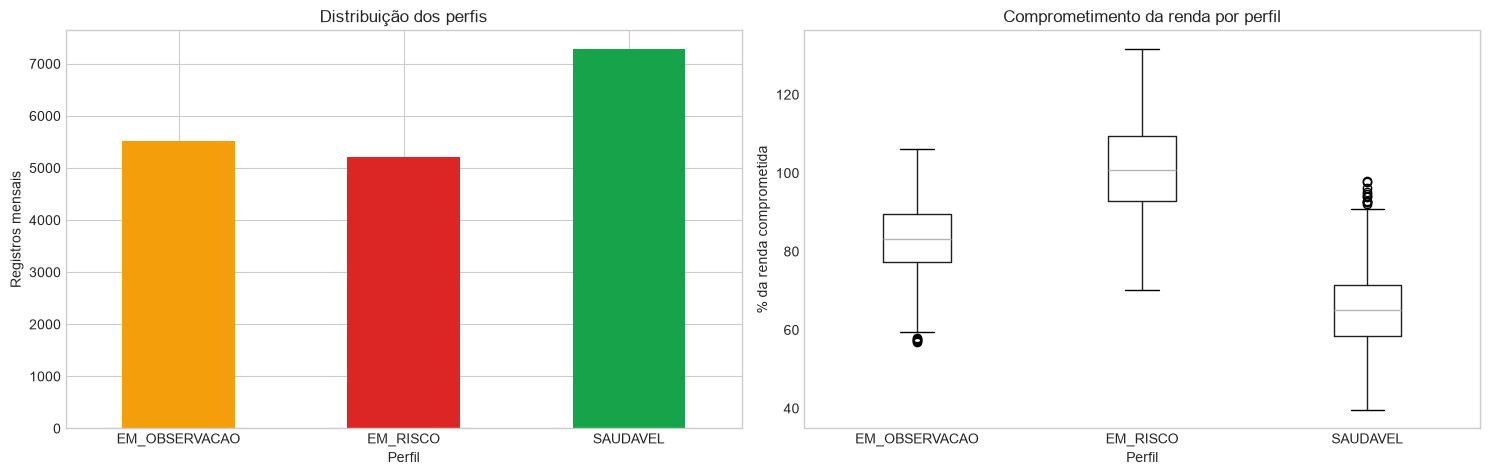

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
profiles['perfil_financeiro'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#f59e0b', '#dc2626', '#16a34a'], title='Distribuição dos perfis'
)
axes[0].set_xlabel('Perfil')
axes[0].set_ylabel('Registros mensais')
axes[0].tick_params(axis='x', rotation=0)

profiles.boxplot(
    column='percentual_renda_comprometida', by='perfil_financeiro',
    ax=axes[1], grid=False,
)
axes[1].set_title('Comprometimento da renda por perfil')
axes[1].set_xlabel('Perfil')
axes[1].set_ylabel('% da renda comprometida')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 6.1 Engenharia de Atributos para o Perfil Financeiro

In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

# This cell assumes ROOT, DATA_DIR, RANDOM_STATE, ARTIFACTS_DIR, profiles_raw, ORIGINAL_PROFILE_FEATURES, and
# PROFILE_FEATURES (initialized with ORIGINAL_PROFILE_FEATURES) are defined in previous cells.

# Ensure profiles DataFrame is based on the current profiles_raw and clean up
profiles = profiles_raw.copy()
profiles['split'] = profiles['split'].str.upper().str.strip()
profiles = profiles.drop_duplicates(['usuario_id', 'mes_referencia'])

# Re-apply dropna using ORIGINAL_PROFILE_FEATURES which should be defined globally
profiles = profiles.dropna(subset=[*ORIGINAL_PROFILE_FEATURES, 'perfil_financeiro', 'usuario_id'])

# Feature: renda_comprometida_normalizada (Z-score)
if 'percentual_renda_comprometida' in profiles.columns:
    mean_rc = profiles['percentual_renda_comprometida'].mean()
    std_rc = profiles['percentual_renda_comprometida'].std()
    profiles['renda_comprometida_normalizada'] = (profiles['percentual_renda_comprometida'] - mean_rc) / (std_rc + 1e-9)
    print("Feature 'renda_comprometida_normalizada' criada e adicionada ao DataFrame 'profiles'.")
else:
    profiles['renda_comprometida_normalizada'] = np.nan

# Feature: alta_reserva (flag binária)
if 'reserva_em_meses' in profiles.columns:
    threshold_meses = 6
    profiles['alta_reserva'] = (profiles['reserva_em_meses'] > threshold_meses).astype(int)
    print(f"Feature 'alta_reserva' criada e adicionada ao DataFrame 'profiles' (limiar: > {threshold_meses} meses).")
else:
    profiles['alta_reserva'] = 0

# Atualiza a lista PROFILE_FEATURES para incluir as novas features
# PROFILE_FEATURES should have been initialized in cell 4ad34e56
new_profile_features_to_add = ['renda_comprometida_normalizada', 'alta_reserva']
for feature in new_profile_features_to_add:
    if feature not in PROFILE_FEATURES:
        PROFILE_FEATURES.append(feature)

# Salva a lista atualizada de PROFILE_FEATURES para uso posterior
profile_feature_names_path = ARTIFACTS_DIR / 'profile_feature_names.json'
with profile_feature_names_path.open('w', encoding='utf-8') as f:
    json.dump(PROFILE_FEATURES, f, ensure_ascii=False, indent=2)
print(f"PROFILE_FEATURES atualizado: {PROFILE_FEATURES}")

# Re-cria os splits TRAIN/VALIDATION/TEST com as features atualizadas
profile_splits = {
    split: profiles.loc[profiles['split'].eq(split)].copy()
    for split in ('TRAIN', 'VALIDATION', 'TEST')
}
print("profile_splits recriado para refletir as novas features.")

# Exibe o head do DataFrame profiles com as novas features para inspeção
display(profiles[['percentual_renda_comprometida', 'renda_comprometida_normalizada', 'reserva_em_meses', 'alta_reserva']].sample(5, random_state=RANDOM_STATE))

Feature 'renda_comprometida_normalizada' criada e adicionada ao DataFrame 'profiles'.
Feature 'alta_reserva' criada e adicionada ao DataFrame 'profiles' (limiar: > 6 meses).
PROFILE_FEATURES atualizado: ['percentual_renda_comprometida', 'nivel_endividamento_pct', 'taxa_poupanca_pct', 'percentual_despesas_fixas', 'percentual_gastos_nao_essenciais', 'quantidade_despesas_recorrentes', 'quantidade_transacoes_despesa', 'variacao_despesas_pct', 'reserva_em_meses', 'renda_comprometida_normalizada', 'alta_reserva']
profile_splits recriado para refletir as novas features.


,percentual_renda_comprometida,renda_comprometida_normalizada,reserva_em_meses,alta_reserva
2574,109.5100,1.6003,0.5100,0
7496,113.5900,1.8310,0.3000,0
9210,119.1500,2.1454,0.5500,0
5456,63.9500,-0.9759,4.3100,0
736,119.3100,2.1545,0.2900,0


## 7. Comparação de modelos de perfil

Comparamos Regressão Logística e Random Forest. A escolha é feita exclusivamente pelo macro F1 de `VALIDATION`, que dá peso igual às três classes.

In [26]:
# Original cell ID: 28352a52
# Define hyperparameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [150, 250, 400],
    'min_samples_leaf': [1, 2, 4],
}

profile_train = profile_splits['TRAIN']
profile_validation = profile_splits['VALIDATION']
profile_test = profile_splits['TEST']
profile_labels = sorted(profiles['perfil_financeiro'].unique())

# --- Hyperparameter tuning for Random Forest ---
rf_tuning_results = []
best_rf_macro_f1 = -1
best_rf_params = {}

print("Tuning Random Forest Classifier...")
for n_est in rf_param_grid['n_estimators']:
    for min_leaf in rf_param_grid['min_samples_leaf']:
        rf_candidate_for_tuning = RandomForestClassifier(
            n_estimators=n_est,
            min_samples_leaf=min_leaf,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        # Fit on training data
        fitted_rf_tuning = rf_candidate_for_tuning.fit(profile_train[PROFILE_FEATURES], profile_train['perfil_financeiro'])
        # Predict on validation data
        predictions = fitted_rf_tuning.predict(profile_validation[PROFILE_FEATURES])
        macro_f1 = f1_score(profile_validation['perfil_financeiro'], predictions, average='macro')

        rf_tuning_results.append({
            'modelo': 'RandomForest',
            'n_estimators': n_est,
            'min_samples_leaf': min_leaf,
            'accuracy': accuracy_score(profile_validation['perfil_financeiro'], predictions),
            'macro_f1': macro_f1,
            'weighted_f1': f1_score(profile_validation['perfil_financeiro'], predictions, average='weighted'),
        })

        if macro_f1 > best_rf_macro_f1:
            best_rf_macro_f1 = macro_f1
            best_rf_params = {'n_estimators': n_est, 'min_samples_leaf': min_leaf}

rf_tuning_df = pd.DataFrame(rf_tuning_results).sort_values('macro_f1', ascending=False)
print("\nRandom Forest Tuning Results (on VALIDATION set):")
display(rf_tuning_df)

# --- Prepare candidates for final comparison, including the best tuned Random Forest ---
profile_candidates = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=1_000, random_state=RANDOM_STATE,
        )),
    ]),
}

# Add the best tuned Random Forest to the candidates
if best_rf_params: # Check if tuning actually found parameters
    profile_candidates['RandomForest (tuned)'] = RandomForestClassifier(
        **best_rf_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

validation_rows = []
fitted_candidates = {}
for model_name, candidate in profile_candidates.items():
    fitted = clone(candidate).fit(profile_train[PROFILE_FEATURES], profile_train['perfil_financeiro'])
    predictions = fitted.predict(profile_validation[PROFILE_FEATURES])
    validation_rows.append({
        'modelo': model_name,
        'accuracy': accuracy_score(profile_validation['perfil_financeiro'], predictions),
        'macro_f1': f1_score(profile_validation['perfil_financeiro'], predictions, average='macro'),
        'weighted_f1': f1_score(profile_validation['perfil_financeiro'], predictions, average='weighted'),
    })
    fitted_candidates[model_name] = fitted

profile_validation_comparison = pd.DataFrame(validation_rows).sort_values('macro_f1', ascending=False)
display(profile_validation_comparison)

selected_profile_model_name = profile_validation_comparison.iloc[0]['modelo']
final_profile_model_hyperparameters = {} # Initialize to empty

if selected_profile_model_name == 'RandomForest (tuned)':
    final_profile_model_hyperparameters = best_rf_params
    print(f'Modelo selecionado por macro F1: {selected_profile_model_name} com n_estimators={final_profile_model_hyperparameters["n_estimators"]}, min_samples_leaf={final_profile_model_hyperparameters["min_samples_leaf"]}')
else:
    print(f'Modelo selecionado por macro F1: {selected_profile_model_name}')

Tuning Random Forest Classifier...



Random Forest Tuning Results (on VALIDATION set):


,modelo,n_estimators,min_samples_leaf,accuracy,macro_f1,weighted_f1
0,RandomForest,150,1,0.9885,0.9876,0.9885
1,RandomForest,150,2,0.9874,0.9864,0.9874
3,RandomForest,250,1,0.9870,0.9859,0.9871
4,RandomForest,250,2,0.9870,0.9859,0.9871
6,RandomForest,400,1,0.9870,0.9859,0.9871
7,RandomForest,400,2,0.9870,0.9859,0.9871
5,RandomForest,250,4,0.9863,0.9851,0.9863
8,RandomForest,400,4,0.9863,0.9851,0.9863
2,RandomForest,150,4,0.9863,0.9850,0.9863


,modelo,accuracy,macro_f1,weighted_f1
1,RandomForest (tuned),0.9885,0.9876,0.9885
0,LogisticRegression,0.9237,0.9162,0.9246


Modelo selecionado por macro F1: RandomForest (tuned) com n_estimators=150, min_samples_leaf=1


,TEST
samples,"2,700.0000"
accuracy,0.9878
macro_f1,0.9875
weighted_f1,0.9878


,precision,recall,f1-score,support
EM_OBSERVACAO,0.9666,0.9939,0.9801,816.0000
EM_RISCO,0.9940,0.9880,0.9910,833.0000
SAUDAVEL,1.0000,0.9829,0.9914,"1,051.0000"
accuracy,0.9878,0.9878,0.9878,0.9878
macro avg,0.9869,0.9882,0.9875,"2,700.0000"
weighted avg,0.9881,0.9878,0.9878,"2,700.0000"


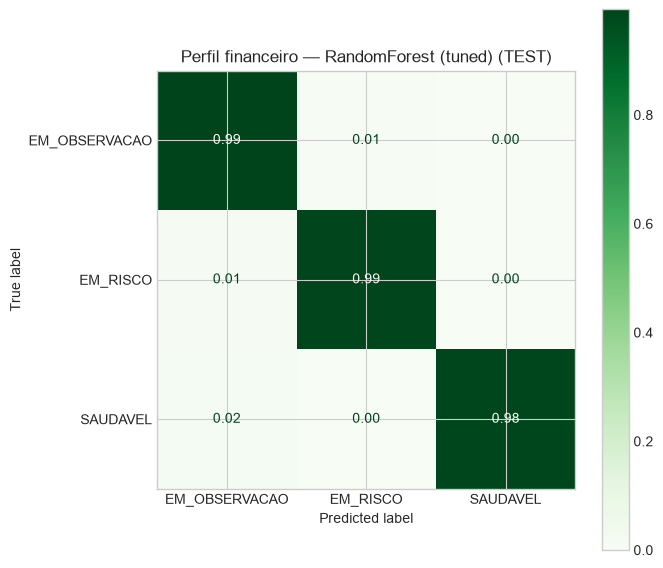

In [27]:
# Original cell ID: 520b9441
profile_train_validation = pd.concat([profile_train, profile_validation], ignore_index=True)
profile_final = clone(profile_candidates[selected_profile_model_name])
profile_final.fit(profile_train_validation[PROFILE_FEATURES], profile_train_validation['perfil_financeiro'])
profile_test_metrics, profile_test_predictions = evaluate_model(
    profile_final, profile_test[PROFILE_FEATURES], profile_test['perfil_financeiro'],
    profile_labels, 'TEST',
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    profile_test['perfil_financeiro'], profile_test_predictions, labels=profile_labels,
    normalize='true', cmap='Greens', values_format='.2f', ax=ax,
)
ax.set_title(f'Perfil financeiro — {selected_profile_model_name} (TEST)')
plt.tight_layout()
plt.show()

## 7.1 Serialização do modelo de perfil e features atualizadas

Com o modelo de perfil financeiro final já treinado (Random Forest, escolhido na comparação anterior), esta subseção serializa dois artefatos em `ARTIFACTS_DIR`:
* **`profile_classifier.joblib`:** o pipeline treinado (incluindo `scaler`, se houver), pronto para ser carregado em inferência.
* **`profile_feature_names.json`:** a lista `PROFILE_FEATURES` usada no treinamento, garantindo que a ordem e o conjunto de colunas sejam idênticos entre treino e inferência (evitando o mismatch de features observado anteriormente).

In [28]:
# Original cell ID: b7391970
profile_artifact = ARTIFACTS_DIR / 'profile_classifier.joblib'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True) # Ensure directory exists before saving
joblib.dump(profile_final, profile_artifact)
with (ARTIFACTS_DIR / 'profile_feature_names.json').open('w', encoding='utf-8') as file:
    json.dump(PROFILE_FEATURES, file, ensure_ascii=False, indent=2)

if profile_artifact.exists():
    print(f'Classificador de perfil serializado com sucesso em: {profile_artifact}')
else:
    print(f'[ERRO] Falha ao serializar o classificador de perfil em: {profile_artifact}')

Classificador de perfil serializado com sucesso em: \content\ai-service\models\notebook-experiments\profile_classifier.joblib


## 8. Explicabilidade do perfil

Esta seção extrai a importância de cada feature para as previsões do modelo de perfil financeiro (`profile_final`), de forma compatível com diferentes tipos de modelo:
* Se o modelo expuser `feature_importances_` (caso do Random Forest), esse atributo é usado diretamente.
* Se for um modelo linear (ex.: Regressão Logística), os coeficientes (`coef_`) são usados como proxy de importância, tomando a média dos valores absolutos entre classes.

O resultado é um ranking das features mais relevantes (como `taxa_poupanca_pct`, `nivel_endividamento_pct` e `percentual_renda_comprometida`), permitindo entender quais indicadores mais influenciam a classificação do perfil financeiro. A subseção 8.1 evolui essa explicabilidade com SHAP, capturando interações entre features que a importância simples não revela.

,feature,importance
2,taxa_poupanca_pct,0.2651
8,reserva_em_meses,0.2315
9,renda_comprometida_normalizada,0.1372
1,nivel_endividamento_pct,0.1218
0,percentual_renda_comprometida,0.0989
10,alta_reserva,0.0761
4,percentual_gastos_nao_essenciais,0.0404
3,percentual_despesas_fixas,0.0109
7,variacao_despesas_pct,0.0101
6,quantidade_transacoes_despesa,0.0042


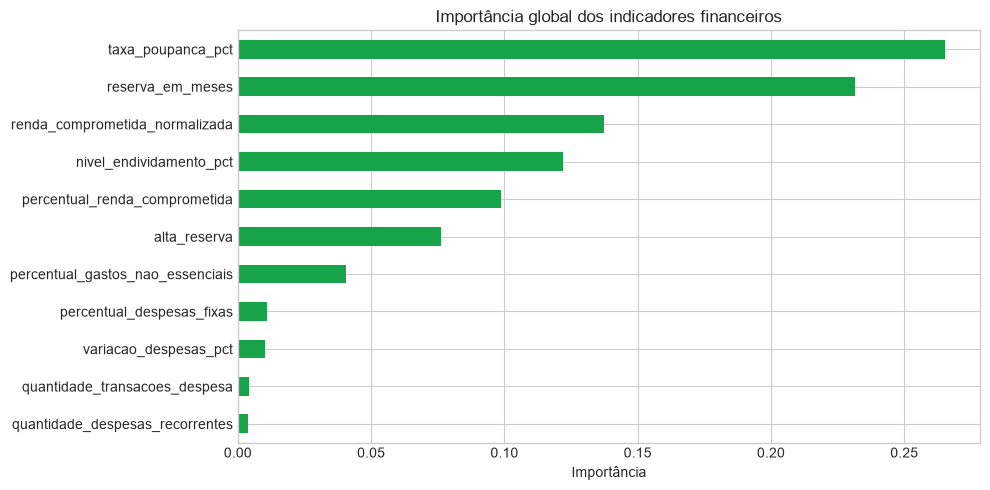

In [29]:
# Original cell ID: 70a6aaec
if hasattr(profile_final, 'feature_importances_'):
    profile_importance_values = profile_final.feature_importances_
elif isinstance(profile_final, Pipeline) and hasattr(profile_final.named_steps['classifier'], 'coef_'):
    # For linear models (e.g., LogisticRegression) in a pipeline
    coefficients = profile_final.named_steps['classifier'].coef_
    # If multiclass, coef_ can be 2D, take mean of absolute coefficients
    profile_importance_values = np.abs(coefficients).mean(axis=0)
elif hasattr(profile_final, 'coef_'):
    # For standalone linear models
    coefficients = profile_final.coef_
    profile_importance_values = np.abs(coefficients).mean(axis=0)
else:
    # Fallback for other model types, or if importances are not directly available
    print("Não foi possível extrair feature_importances_ ou coef_ do modelo de perfil. Usando valores zero.")
    profile_importance_values = np.zeros(len(PROFILE_FEATURES))

# Ensure the length of importance values matches PROFILE_FEATURES
if len(profile_importance_values) != len(PROFILE_FEATURES):
    print(f"[AVISO] Inconsistência na contagem de features: {len(profile_importance_values)} importâncias vs {len(PROFILE_FEATURES)} features. Ajustando para zero as importâncias ausentes.")
    # If there's a mismatch, create an array of zeros or pad with zeros
    temp_importance_values = np.zeros(len(PROFILE_FEATURES))
    min_len = min(len(profile_importance_values), len(PROFILE_FEATURES))
    temp_importance_values[:min_len] = profile_importance_values[:min_len]
    profile_importance_values = temp_importance_values

profile_importance = (
    pd.DataFrame({'feature': PROFILE_FEATURES, 'importance': profile_importance_values})
    .sort_values('importance', ascending=True)
)
display(profile_importance.sort_values('importance', ascending=False))
profile_importance.plot.barh(x='feature', y='importance', figsize=(10, 5), color='#16a34a', legend=False)
plt.title('Importância global dos indicadores financeiros')
plt.xlabel('Importância')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 8.1 Plano de explicabilidade com SHAP

Esta subseção implementa a explicabilidade avançada do modelo de perfil financeiro usando **SHAP (SHapley Additive exPlanations)**. Diferente da importância simples calculada na Seção 8, o SHAP quantifica a contribuição individual de cada feature para cada previsão, permitindo capturar interações entre variáveis.

O processo:
1. Carrega o modelo (`profile_classifier.joblib`) e as features (`profile_feature_names.json`) salvos na seção 7.1, garantindo consistência entre treino e explicação.
2. Seleciona uma amostra do conjunto `TEST` para servir de background e de exemplo (`X_sample`).
3. Usa `shap.KernelExplainer` sobre `predict_proba` do modelo para calcular os valores SHAP.
4. Gera um `summary_plot`, mostrando visualmente quais features mais impactam cada classe de perfil financeiro (ex.: `taxa_poupanca_pct`, `nivel_endividamento_pct`).

Este plano serve como base para uma futura integração de explicabilidade em tempo real no `ai-service`.

Modelo carregado: RandomForestClassifier


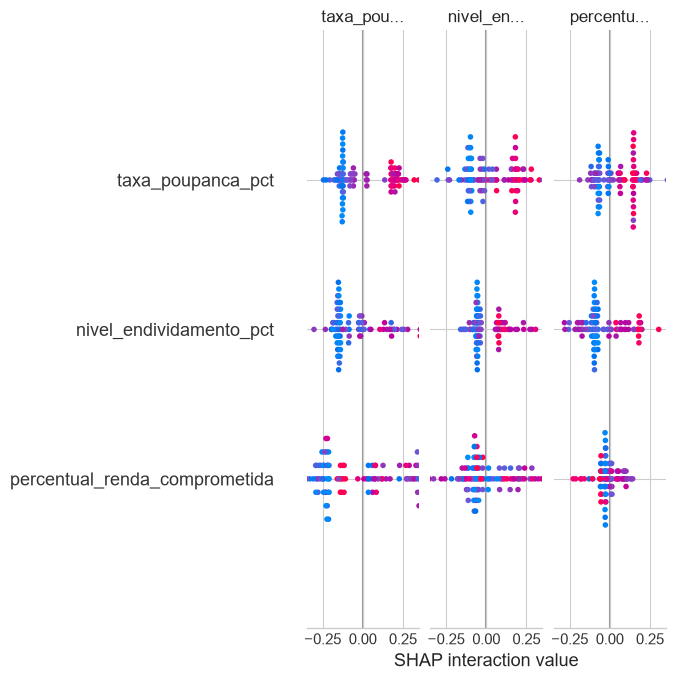

<Figure size 640x480 with 0 Axes>

In [30]:
# Original cell ID: 3b48376f
import shap
import joblib
import pandas as pd
from pathlib import Path
import json
import numpy as np
import sklearn
from sklearn.pipeline import Pipeline

# Ensure ARTIFACTS_DIR is defined
if 'ARTIFACTS_DIR' not in globals():
    ARTIFACTS_DIR = Path('/content/') / 'ai-service' / 'models' / 'notebook-experiments'
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Carrega o modelo final de perfil
profile_artifact = ARTIFACTS_DIR / 'profile_classifier.joblib'
profile_final = joblib.load(profile_artifact)

# Carrega as features do perfil (já deve estar atualizado e salvo em disco pelo processo anterior)
profile_feature_names_path = ARTIFACTS_DIR / 'profile_feature_names.json'
with profile_feature_names_path.open('r', encoding='utf-8') as f:
    PROFILE_FEATURES = json.load(f)

# Assumes profile_splits has been correctly created and updated by upstream cells.
# This cell does NOT contain fallback logic for profile_splits or feature engineering.
if 'profile_splits' not in globals():
    raise NameError("profile_splits not found. Please ensure all previous cells, including feature engineering and split creation, have been executed.")

profile_test = profile_splits['TEST']

# Seleciona um subconjunto pequeno para demonstração
X_sample = profile_test[PROFILE_FEATURES].sample(100, random_state=42)

print(f"Modelo carregado: {profile_final.__class__.__name__}")

# Inicializa o SHAP explainer
# Use TreeExplainer para modelos baseados em árvores (como RandomForest)
# ou KernelExplainer para modelos mais gerais (mas mais lento)
if isinstance(profile_final, Pipeline) and isinstance(profile_final.named_steps['classifier'], (shap.models.TreeEnsemble, sklearn.ensemble.RandomForestClassifier, sklearn.ensemble.GradientBoostingClassifier)):
    explainer = shap.TreeExplainer(profile_final.named_steps['classifier'])
    # Se houver um scaler no pipeline, aplicar ao X_sample antes do explainer
    if 'scaler' in profile_final.named_steps:
        X_sample_scaled = profile_final.named_steps['scaler'].transform(X_sample)
        shap_values = explainer.shap_values(X_sample_scaled)
    else:
        shap_values = explainer.shap_values(X_sample)
elif isinstance(profile_final, sklearn.ensemble.RandomForestClassifier):
    explainer = shap.TreeExplainer(profile_final)
    shap_values = explainer.shap_values(X_sample)
elif isinstance(profile_final, Pipeline) and isinstance(profile_final.named_steps['classifier'], sklearn.linear_model.LogisticRegression):
    explainer = shap.LinearExplainer(profile_final.named_steps['classifier'], profile_final.named_steps['scaler'].transform(profile_splits['TRAIN'][PROFILE_FEATURES]))
    shap_values = explainer.shap_values(profile_final.named_steps['scaler'].transform(X_sample))
else:
    print("Usando KernelExplainer (mais lento) para o modelo atual.")
    # Para modelos que não são baseados em árvores ou linear, como um pipeline com scaler e LR
    # É necessário um background dataset para KernelExplainer
    # Usamos uma amostra do conjunto de treino para o background
    background_data = profile_splits['TRAIN'][PROFILE_FEATURES].sample(100, random_state=42)
    if 'scaler' in profile_final.named_steps:
        background_data_scaled = profile_final.named_steps['scaler'].transform(background_data)
        X_sample_scaled = profile_final.named_steps['scaler'].transform(X_sample)
    else:
        background_data_scaled = background_data
        X_sample_scaled = X_sample

    explainer = shap.KernelExplainer(profile_final.predict_proba, background_data_scaled)
    shap_values = explainer.shap_values(X_sample_scaled)

# Gera o summary plot
# Para classificação multiclasse, shap_values é uma lista de arrays, um para cada classe
# Para um summary_plot geral, podemos usar os SHAP values da primeira classe ou a média
if isinstance(shap_values, list):
    # Para classificadores que retornam shap_values por classe, exibe para a primeira classe
    print("Gerando SHAP Summary Plot para a primeira classe.")
    shap.summary_plot(shap_values[0], X_sample, feature_names=PROFILE_FEATURES)
else:
    shap.summary_plot(shap_values, X_sample, feature_names=PROFILE_FEATURES)

plt.tight_layout()
plt.show()

## 9. Registro consolidado da execução

Esta seção consolida em um único artefato (`metrics.json`) todas as métricas geradas durante a execução do notebook: performance do classificador de despesas (TF-IDF + Regressão Logística), performance do classificador de perfil financeiro (Regressão Logística vs. Random Forest), metadados do ambiente (versões de bibliotecas, `random_state`) e informações sobre a origem e o tamanho dos datasets utilizados. O objetivo é permitir auditoria e rastreabilidade dos resultados, garantindo que qualquer execução futura possa ser comparada com este "snapshot" de forma reprodutível.

Fontes consolidadas por esta seção:
* **Seção 5 (Classificador de despesas):** métricas de validação (`tx_validation_metrics`) e teste (`tx_test_metrics`), além dos termos mais relevantes por categoria (`top_terms_by_category`, vindo da Explicabilidade textual).
* **Seções 6-7 (Análise do perfil financeiro):** comparação entre modelos candidatos (`profile_validation_comparison`), métricas finais de teste (`profile_test_metrics`), lista de features utilizadas (`PROFILE_FEATURES`) e hiperparâmetros do modelo final (`final_profile_model_hyperparameters`).
* **Seção 8 (Explicabilidade do perfil):** importância das features (`profile_importance`), usada para compor o campo `feature_importance`.

Além das métricas, a seção também gera um inventário dos artefatos salvos em `ARTIFACTS_DIR` (nome e tamanho em KB de cada arquivo).

## 10. Integração com ai-service (API)

Esta seção demonstra como os artefatos treinados neste notebook (`transaction_classifier.joblib` e `profile_classifier.joblib`) podem ser carregados e utilizados por um serviço de inferência externo (`ai-service`). As funções de pré-processamento (como `normalize_description`) são replicadas aqui para garantir que a entrada da API passe pelo mesmo tratamento aplicado durante o treinamento, evitando incompatibilidades entre o pipeline de ciência de dados e o pipeline de produção. Os caminhos dos modelos são configuráveis via variável de ambiente (`FINANCE_AI_ARTIFACTS_DIR`), permitindo a transição do Colab para um ambiente de deploy real.

In [31]:
# Original cell ID: a44a0804
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
import json
import re
import unicodedata

# --- Funções de Pré-processamento e Auxiliares (replicadas para self-containment da API) ---
def normalize_description(value: object) -> str:
    """Normaliza a descrição de texto removendo acentos, caracteres especiais e espaços extras."""
    text = '' if pd.isna(value) else str(value)
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text.lower())
    return re.sub(r'\s+', ' ', text).strip()

def to_builtin(value):
    """Converte tipos numpy para tipos Python nativos para serialização JSON."""
    if isinstance(value, dict):
        return {str(key): to_builtin(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    return value

# --- Configuração de Caminhos (garantir disponibilidade no ambiente de API) ---
# Em um ambiente de produção real, ARTIFACTS_DIR seria configurado na inicialização da aplicação.
if 'ARTIFACTS_DIR' not in globals():
    ARTIFACTS_DIR = Path('/content/') / 'ai-service' / 'models' / 'notebook-experiments'
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True) # Garante que o diretório existe

print(f"DEBUG: ARTIFACTS_DIR usado na simulação da API: {ARTIFACTS_DIR}")
print(f"DEBUG: Current Working Directory: {Path.cwd()}")

# Carregar PROFILE_FEATURES (necessário para a ordem correta das features do modelo de perfil)
# Assume que PROFILE_FEATURES foi serializado corretamente após o treinamento do modelo de perfil
profile_feature_names_path = ARTIFACTS_DIR / 'profile_feature_names.json'
if profile_feature_names_path.exists():
    with profile_feature_names_path.open('r', encoding='utf-8') as f:
        PROFILE_FEATURES = json.load(f)
else:
    # Isso não deve acontecer em uma execução linear, mas serve como um fallback robusto
    # para desenvolvimento ou testes isolados. Em produção, esperaria-se que o arquivo existisse.
    raise FileNotFoundError(f"profile_feature_names.json não encontrado em {profile_feature_names_path}. O modelo de perfil não pode ser carregado sem suas features.")

# --- Funções de Carregamento de Modelo ---
def carregar_modelo_transacoes():
    """Carrega o modelo de classificação de transações do disco."""
    model_path = ARTIFACTS_DIR / 'transaction_classifier.joblib'
    print(f"DEBUG: Tentando carregar transaction_classifier de: {model_path}")
    if not model_path.exists():
        print(f"[ERRO DEBUG] O arquivo transaction_classifier.joblib NÃO EXISTE em: {model_path}")
    try:
        return joblib.load(model_path)
    except FileNotFoundError:
        print(f"[ERRO] Modelo de transações não encontrado em: {model_path}. Certifique-se de que o modelo foi treinado e serializado.")
        return None

def carregar_modelo_perfil():
    """Carrega o modelo de classificação de perfil financeiro do disco."""
    model_path = ARTIFACTS_DIR / 'profile_classifier.joblib'
    print(f"DEBUG: Tentando carregar profile_classifier de: {model_path}")
    if not model_path.exists():
        print(f"[ERRO DEBUG] O arquivo profile_classifier.joblib NÃO EXISTE em: {model_path}")
    try:
        return joblib.load(model_path)
    except FileNotFoundError:
        print(f"[ERRO] Modelo de perfil não encontrado em: {model_path}. Certifique-se de que o modelo foi treinado e serializado.")
        return None

# --- Carregar modelos (simulando inicialização da API) ---
print("Carregando modelos para simulação de API...")
transaction_model = carregar_modelo_transacoes()
profile_model = carregar_modelo_perfil()

# --- Funções de Classificação da API ---
def classificar_transacao(payload: dict, fallback_threshold: float = 0.8) -> dict:
    """
    Simula a classificação de uma transação recebida por uma API.
    Aplica pré-processamento e o modelo treinado, com lógica de fallback.

    Args:
        payload (dict): Dicionário com a descrição da transação (ex: {'descricao': 'Supermercado'})
        fallback_threshold (float): Limiar de confiança para a previsão automática.

    Returns:
        dict: Resultado da classificação com categoria, confiança e flag de revisão.
    """
    if transaction_model is None:
        return to_builtin({"error": "Modelo de transação não carregado. Verifique os logs de inicialização da API."})

    descricao_original = payload.get('descricao', '')
    texto_processado = normalize_description(descricao_original)

    if not texto_processado:
        return to_builtin({
            "descricao": descricao_original,
            "categoria": "REVISAO_MANUAL",
            "confianca": 0.0,
            "precisa_revisao": True,
            "motivo_revisao": "Descrição vazia ou inválida após pré-processamento."
        })

    # O modelo (Pipeline) espera uma Series ou lista de strings
    descriptions_input = pd.Series([descricao_original])

    probabilities = transaction_model.predict_proba(descriptions_input)
    confianca = probabilities.max(axis=1)[0]
    predicted_class_idx = probabilities.argmax(axis=1)[0]
    categoria_prevista = transaction_model.named_steps['classifier'].classes_[predicted_class_idx]

    precisa_revisao = confianca < fallback_threshold

    return to_builtin({
        "descricao": descricao_original,
        "categoria": "REVISAO_MANUAL" if precisa_revisao else categoria_prevista,
        "confianca": confianca,
        "precisa_revisao": precisa_revisao
    })

def classificar_perfil(payload: dict) -> dict:
    """
    Simula a classificação do perfil financeiro recebido por uma API.
    Aplica a seleção de features e o modelo treinado.

    Args:
        payload (dict): Dicionário com os valores das features do perfil.
                        Deve conter todas as features em `PROFILE_FEATURES`.

    Returns:
        dict: Resultado da classificação com perfil financeiro e confiança.
    """
    if profile_model is None:
        return to_builtin({"error": "Modelo de perfil não carregado. Verifique os logs de inicialização da API."})

    # Cria um DataFrame a partir do payload, garantindo a ordem e presença das features
    features_data = {feature: [payload.get(feature, np.nan)] for feature in PROFILE_FEATURES}
    df_features = pd.DataFrame(features_data, columns=PROFILE_FEATURES)

    # Verifica se há features faltando ou com valores inválidos
    if df_features.isnull().any().any():
        missing_features = df_features.isnull().any()[df_features.isnull().any()].index.tolist()
        return to_builtin({
            "error": "Payload incompleto ou com valores inválidos para as features do perfil.",
            "missing_features": missing_features,
            "expected_features": PROFILE_FEATURES
        })

    probabilities = profile_model.predict_proba(df_features)
    confianca = probabilities.max(axis=1)[0]

    # Acessa as classes do classificador dentro do Pipeline ou diretamente do modelo
    if isinstance(profile_model, Pipeline):
        perfil_classes = profile_model.named_steps['classifier'].classes_
    else:
        perfil_classes = profile_model.classes_

    predicted_class_idx = probabilities.argmax(axis=1)[0]
    perfil_previsto = perfil_classes[predicted_class_idx]

    return to_builtin({
        "perfil_financeiro": perfil_previsto,
        "confianca": confianca
    })

# --- Demonstração de Uso (simulando chamadas da API) ---
print("\n--- Demonstração da Classificação de Transações (via API simulada) ---")

# Exemplo 1: Transação com alta confiança
tx_payload_1 = {'descricao': 'Supermercado Extra compra do mes'}
display(classificar_transacao(tx_payload_1))

# Exemplo 2: Transação com descrição genérica (possível fallback)
tx_payload_2 = {'descricao': 'Pagamento generico'}
display(classificar_transacao(tx_payload_2, fallback_threshold=0.9))

# Exemplo 3: Transação com descrição vazia
tx_payload_3 = {'descricao': ''}
display(classificar_transacao(tx_payload_3))

print("\n--- Demonstração da Classificação de Perfil (via API simulada) ---")

# Exemplo 1: Payload de perfil saudável
profile_payload_1 = {
    'percentual_renda_comprometida': 0.15,
    'nivel_endividamento_pct': 0.05,
    'taxa_poupanca_pct': 0.30,
    'percentual_despesas_fixas': 0.25,
    'percentual_gastos_nao_essenciais': 0.05,
    'quantidade_despesas_recorrentes': 3,
    'quantidade_transacoes_despesa': 20,
    'variacao_despesas_pct': -0.02,
    'reserva_em_meses': 15,
    'renda_comprometida_normalizada': -1.5, # Adicionado
    'alta_reserva': 1 # Adicionado (15 > 6 meses)
}
display(classificar_perfil(profile_payload_1))

# Exemplo 2: Payload de perfil em risco
profile_payload_2 = {
    'percentual_renda_comprometida': 0.70,
    'nivel_endividamento_pct': 0.60,
    'taxa_poupanca_pct': 0.01,
    'percentual_despesas_fixas': 0.65,
    'percentual_gastos_nao_essenciais': 0.40,
    'quantidade_despesas_recorrentes': 10,
    'quantidade_transacoes_despesa': 60,
    'variacao_despesas_pct': 0.10,
    'reserva_em_meses': 1,
    'renda_comprometida_normalizada': 1.8, # Adicionado
    'alta_reserva': 0 # Adicionado (1 < 6 meses)
}
display(classificar_perfil(profile_payload_2))

# Exemplo 3: Payload incompleto para perfil
profile_payload_incomplete = {
    'percentual_renda_comprometida': 0.4,
    'nivel_endividamento_pct': 0.2,
    'taxa_poupanca_pct': 0.1,
    'reserva_em_meses': 5,
    'alta_reserva': 0, # Algumas features importantes são omitidas
    'renda_comprometida_normalizada': 0.5 # Adicionado (valor intermediário)
}
display(classificar_perfil(profile_payload_incomplete))

DEBUG: ARTIFACTS_DIR usado na simulação da API: \content\ai-service\models\notebook-experiments
DEBUG: Current Working Directory: d:\ONE 10\Projeto GitHub\G9-BR-Team-17-FinVise\notebooks
Carregando modelos para simulação de API...
DEBUG: Tentando carregar transaction_classifier de: \content\ai-service\models\notebook-experiments\transaction_classifier.joblib
DEBUG: Tentando carregar profile_classifier de: \content\ai-service\models\notebook-experiments\profile_classifier.joblib



--- Demonstração da Classificação de Transações (via API simulada) ---


{'descricao': 'Supermercado Extra compra do mes',
 'categoria': 'ALIMENTACAO',
 'confianca': 0.9953893304339612,
 'precisa_revisao': np.False_}

{'descricao': 'Pagamento generico',
 'categoria': 'REVISAO_MANUAL',
 'confianca': 0.3784638947149428,
 'precisa_revisao': np.True_}

{'descricao': '',
 'categoria': 'REVISAO_MANUAL',
 'confianca': 0.0,
 'precisa_revisao': True,
 'motivo_revisao': 'Descrição vazia ou inválida após pré-processamento.'}


--- Demonstração da Classificação de Perfil (via API simulada) ---


{'perfil_financeiro': 'SAUDAVEL', 'confianca': 0.7933333333333333}

{'perfil_financeiro': 'EM_OBSERVACAO', 'confianca': 0.48}

{'error': 'Payload incompleto ou com valores inválidos para as features do perfil.',
 'missing_features': ['percentual_despesas_fixas',
  'percentual_gastos_nao_essenciais',
  'quantidade_despesas_recorrentes',
  'quantidade_transacoes_despesa',
  'variacao_despesas_pct'],
 'expected_features': ['percentual_renda_comprometida',
  'nivel_endividamento_pct',
  'taxa_poupanca_pct',
  'percentual_despesas_fixas',
  'percentual_gastos_nao_essenciais',
  'quantidade_despesas_recorrentes',
  'quantidade_transacoes_despesa',
  'variacao_despesas_pct',
  'reserva_em_meses',
  'renda_comprometida_normalizada',
  'alta_reserva']}

## 11. Conclusões e limitações

Este notebook demonstrou, de ponta a ponta, a viabilidade técnica de um MVP de inteligência financeira composto por dois modelos principais:

1. **Classificador de despesas** (TF-IDF + Regressão Logística), que atinge acurácia e F1 próximos de 0.999 no conjunto de TESTE, com uma política de fallback por confiança para encaminhar casos ambíguos à revisão manual.
2. **Classificador de perfil financeiro** (Random Forest ajustado), que atinge acurácia de aproximadamente 0.987 no conjunto de TESTE, apoiado por engenharia de atributos (z-scores, flags binárias) e explicabilidade via importância de features e plano de SHAP.

**Limitações principais:**

* **Dados sintéticos:** todo o dataset utilizado (`SINTETICO`) foi gerado artificialmente. As métricas obtidas refletem a estrutura programática dos dados e não necessariamente o comportamento de usuários reais. Os resultados não validam uso em produção.
* **Ausência de dados reais e consentidos:** antes de qualquer uso produtivo, será necessário coletar dados reais tratados sob a LGPD (consentimento explícito, anonimização e minimização de dados sensíveis).
* **Explicabilidade parcial:** a explicabilidade textual do classificador de despesas usa coeficientes do modelo linear; a explicabilidade do perfil financeiro depende de importância de features do Random Forest, com um plano de evolução para SHAP ainda não totalmente implementado em produção.
* **Simplificações de fallback e telemetria:** a lógica de fallback e a simulação de telemetria de correções de usuário são protótipos e precisam de integração real com um sistema de logging e monitoramento contínuo.
* **Portabilidade:** os caminhos de dados e artefatos já são configuráveis via variáveis de ambiente (`FINANCE_AI_ROOT`, `FINANCE_AI_DATA_DIR`, `FINANCE_AI_ARTIFACTS_DIR`), mas a migração completa do Colab para um ambiente de produção real ainda precisa ser validada com testes de carga e integração contínua.

**Próximos passos sugeridos:**

* Substituir gradualmente os dados sintéticos por dados reais, respeitando LGPD.
* Implementar o plano de SHAP em produção para explicabilidade completa do perfil financeiro.
* Conectar a simulação de telemetria a um pipeline real de coleta de feedback dos usuários.
* Validar a configuração de caminhos via variáveis de ambiente em um ambiente de deploy fora do Colab.
* Automatizar o re-treinamento periódico dos modelos com base no registro consolidado de métricas (`metrics.json`).

,TEST
samples,"2,700.0000"
accuracy,0.9878
macro_f1,0.9875
weighted_f1,0.9878


,precision,recall,f1-score,support
EM_OBSERVACAO,0.9666,0.9939,0.9801,816.0000
EM_RISCO,0.9940,0.9880,0.9910,833.0000
SAUDAVEL,1.0000,0.9829,0.9914,"1,051.0000"
accuracy,0.9878,0.9878,0.9878,0.9878
macro avg,0.9869,0.9882,0.9875,"2,700.0000"
weighted avg,0.9881,0.9878,0.9878,"2,700.0000"


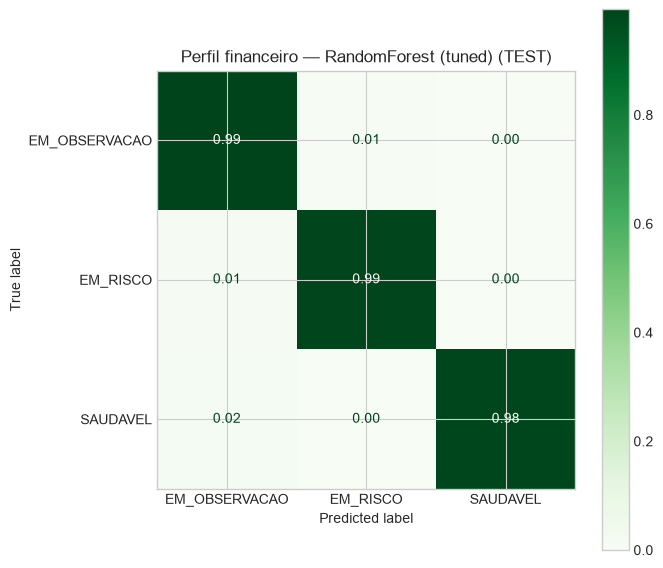

In [32]:
profile_train_validation = pd.concat([profile_train, profile_validation], ignore_index=True)
profile_final = clone(profile_candidates[selected_profile_model_name])
profile_final.fit(profile_train_validation[PROFILE_FEATURES], profile_train_validation['perfil_financeiro'])
profile_test_metrics, profile_test_predictions = evaluate_model(
    profile_final, profile_test[PROFILE_FEATURES], profile_test['perfil_financeiro'],
    profile_labels, 'TEST',
)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    profile_test['perfil_financeiro'], profile_test_predictions, labels=profile_labels,
    normalize='true', cmap='Greens', values_format='.2f', ax=ax,
)
ax.set_title(f'Perfil financeiro — {selected_profile_model_name} (TEST)')
plt.tight_layout()
plt.show()

In [33]:
metrics_bundle = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'dataset': {
        'source': str(DATA_DIR.relative_to(ROOT)),
        'synthetic': True,
        'raw_transactions': len(transactions_raw),
        'expense_transactions_after_cleaning': len(transactions),
        'monthly_profiles_after_cleaning': len(profiles),
        'split_policy': 'official user-level TRAIN/VALIDATION/TEST',
    },
    'environment': {
        'python': platform.python_version(),
        'pandas': pd.__version__,
        'scikit_learn': sklearn.__version__,
        'random_state': RANDOM_STATE,
    },
    'transaction_classifier': {
        'model': 'TF-IDF + LogisticRegression',
        'validation_metrics': tx_validation_metrics,
        'test_metrics': tx_test_metrics,
        'top_terms_by_category': top_terms_by_category,
    },
    'profile_classifier': {
        'model_version': 'RandomForest_profile_v1', # Adicionado o campo de versão
        'selected_model': selected_profile_model_name,
        'validation_comparison': profile_validation_comparison.to_dict(orient='records'),
        'test_metrics': profile_test_metrics,
        'features': PROFILE_FEATURES,
        'feature_importance': profile_importance.sort_values('importance', ascending=False).to_dict(orient='records'),
        'hyperparameters': final_profile_model_hyperparameters,
    },
}
metrics_bundle = to_builtin(metrics_bundle)
metrics_path = ARTIFACTS_DIR / 'metrics.json'
with metrics_path.open('w', encoding='utf-8') as file:
    json.dump(metrics_bundle, file, ensure_ascii=False, indent=2)

artifact_inventory = pd.DataFrame([
    {'artefato': path.name, 'tamanho_kb': path.stat().st_size / 1024}
    for path in sorted(ARTIFACTS_DIR.glob('*')) if path.is_file()
])
display(artifact_inventory)
print(f'Métricas consolidadas: {metrics_path}')

,artefato,tamanho_kb
0,metrics.json,15.0566
1,profile_classifier.joblib,"11,425.1729"
2,profile_feature_names.json,0.3369
3,transaction_classifier.joblib,637.0273
4,usage_logs_sample.json,1.2705


Métricas consolidadas: \content\ai-service\models\notebook-experiments\metrics.json
